# <font color="brown">**Heritage Institute of Technology**
# <font color="brown">**Department of AEIE**
# <font color="brown">**MACHINE LEARNING TECHNIQUES LAB (AEI3262)**
# <font color="brown">**B. Tech AEIE,   6th Semester**
# <font color="Blue">**Experiment No. 10: Feature Learning with Autoencoders. </font>**  **[CO: AEI3262.4]**


# <font color="Blue">**Objective:**
- To learn compressed feature representations using autoencoders.

-	To train an undercomplete autoencoder on a dataset (e.g., MNIST, tabular).
-	To use the encoded feature vectors as input to a separate classifier or regressor.
-	To compare performance of models using raw data vs. compressed representation.
-	To visualize reconstruction error and latent space (if 2D).


# <font color="Blue"> **A: Learning Outcome:**
## After completion of this assignment you will be able to:

*  Apply autoencoder model on a given data set to extract its intrinsic representation.
*  Able to classfy the data using the feature representation.
*  Assess the performance of the model.


# <font color="Blue">**B. Instructions:**
* You will be using Python 3.
* Avoid using for-loops and while-loops, unless you are explicitly told to do so.
* Do not modify the function name, variable names, comments in cells.
* Write your code where it is asked to write.
* After your coding, run the cell and see your results.

# <font color="Blue">**C. Useful PYTHON Commands**
Some useful PYTHON commands that may be required to perform this experiment are given below:
# <font color="magenta">*Requird Library:*
    numpy     pands    sklearn    matplotlib.pyplot

# <font color="magenta"> *Elementary Functions from numpy:*
    np.unique()       

# <font color="magenta">*Functions from matplotlib.pyplot:*
    plt.figure()   plt.plot()     plt.scatter()  plt.title()
    plt.xlabel()   plt.ylabel()   plt.xticks()   plt.yticks()  
    plt.legend()   plt.grid()     plt.show()     plt.text()
    plt.bar()     

# <font color="magenta"> *Elementary Functions from Seaborn:*
    sns.heatmap()

# <font color="magenta">*Modules and Methods of sklearn library:*
    sklearn.preprocessing.MinMaxScaler()
    scaler.transform()
   
    model.fit()
    model.predict()
    from sklearn.datasets import load_digits
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    from sklearn.linear_model import LogisticRegression
    from sklearn.manifold import TSNE

    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import Input, Dense
    from tensorflow.keras.callbacks import EarlyStopping


##<font color="blue"> **Problem-1:**</font> Implement an undercomplete autoencoder for learning compressed feature representations using a suitable dataset (e.g., MNIST, tabular or Digits dataset) using TensorFlow/Keras.

i)	Load the dataset and perform preprocessing:
- Normalize the input data
- Split into training and testing sets (70:30)

ii)	Design and implement an undercomplete autoencoder consisting of:
- Encoder (compression layers)
- Latent space (bottleneck layer)
-	Decoder (reconstruction layers)
iii)	Train the autoencoder to minimize reconstruction error using an appropriate loss function (e.g., mean squared error or binary crossentropy).

iv)	Obtain the encoded (latent) feature representation from the trained encoder.

v)	Train a separate classifier (e.g., Logistic Regression / SVM / Neural Network) using:
-	Original input features
-	Encoded (compressed) features

vi)	Compare the performance of the classifier using:

-	Raw data
-	Compressed features

based on metrics such as:

-	Accuracy
-	Precision
-	Recall
-	F1-score

vii)	Compute and visualize reconstruction error of the autoencoder.

viii)	Visualize original vs reconstructed samples for selected inputs.

ix)	Use t-SNE to visualize the latent feature space in 2D using a scatter plot with class labels.

x)	Analyze the effectiveness of feature compression and summarize the impact of learned representations on model performance.


# <font color="magenta"> **Import Libraries:**

In [1]:
# ==============================
# Import Libraries
# ==============================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping


# <font color="magenta"> **Load & Preprocess Dataset (i):**

In [2]:
data = load_digits()
X = data.data
y = data.target

# Normalize
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Train-test split (70:30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# <font color="magenta"> **Build Autoencoder (ii):**

In [3]:
input_dim = X.shape[1]   # 64
latent_dim = 16          # bottleneck (undercomplete)

# Encoder
inputs = Input(shape=(input_dim,))
encoded = Dense(32, activation='relu')(inputs)
latent = Dense(latent_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(32, activation='relu')(latent)
outputs = Dense(input_dim, activation='sigmoid')(decoded)

# Models
autoencoder = Model(inputs, outputs)
encoder = Model(inputs, latent)

# <font color="magenta"> **Compile & Train (iii):**

In [4]:
autoencoder.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = autoencoder.fit(
    X_train, X_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.1627 - val_loss: 0.1299
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0987 - val_loss: 0.0776
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0747 - val_loss: 0.0708
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0689 - val_loss: 0.0647
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0618 - val_loss: 0.0575
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0555 - val_loss: 0.0518
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0504 - val_loss: 0.0465
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0453 - val_loss: 0.0423
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0418 - val_loss: 0.0394
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0390 - val_loss: 0.0371
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0362 - val_loss: 0.0348
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.

# <font color="magenta"> **Extract Latent Features (iv):**

In [5]:
X_train_latent = encoder.predict(X_train)
X_test_latent = encoder.predict(X_test)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


# <font color="magenta"> **Train Classifiers (v):**

In [6]:
# Raw data classifier
clf_raw = LogisticRegression(max_iter=1000)
clf_raw.fit(X_train, y_train)
y_pred_raw = clf_raw.predict(X_test)

# Latent feature classifier
clf_latent = LogisticRegression(max_iter=1000)
clf_latent.fit(X_train_latent, y_train)
y_pred_latent = clf_latent.predict(X_test_latent)

# <font color="magenta"> **Performance Comparison (vi):**

In [7]:
def compute_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted'),
        "Recall": recall_score(y_true, y_pred, average='weighted'),
        "F1-score": f1_score(y_true, y_pred, average='weighted')
    }

metrics_raw = compute_metrics(y_test, y_pred_raw)
metrics_latent = compute_metrics(y_test, y_pred_latent)

results_df = pd.DataFrame([metrics_raw, metrics_latent],
                          index=["Raw Data", "Latent Features"])

print("\nPerformance Comparison:\n")
print(results_df)


Performance Comparison:

                 Accuracy  Precision    Recall  F1-score
Raw Data         0.966667   0.967073  0.966667  0.966729
Latent Features  0.929630   0.930511  0.929630  0.928998


# <font color="magenta"> **Reconstruction Error (vii):**

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


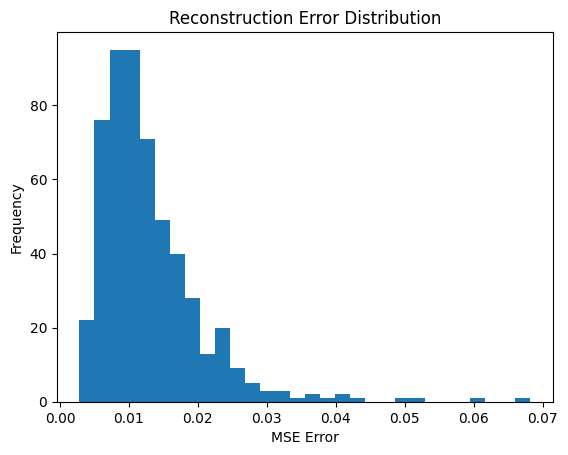

In [8]:
X_test_reconstructed = autoencoder.predict(X_test)

reconstruction_error = np.mean((X_test - X_test_reconstructed)**2, axis=1)

plt.figure()
plt.hist(reconstruction_error, bins=30)
plt.title("Reconstruction Error Distribution")
plt.xlabel("MSE Error")
plt.ylabel("Frequency")
plt.show()

# <font color="magenta"> **Original vs Reconstructed (viii):**

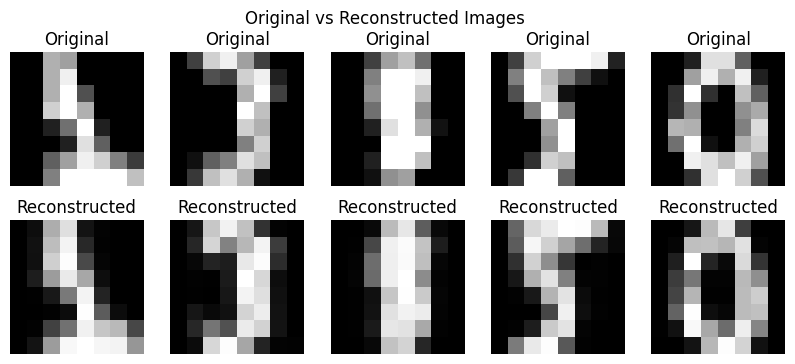

In [9]:
plt.figure(figsize=(10,4))

for i in range(5):
    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(8,8), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2,5,i+6)
    plt.imshow(X_test_reconstructed[i].reshape(8,8), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.suptitle("Original vs Reconstructed Images")
plt.show()

# <font color="magenta"> **t-SNE Visualization (ix):**

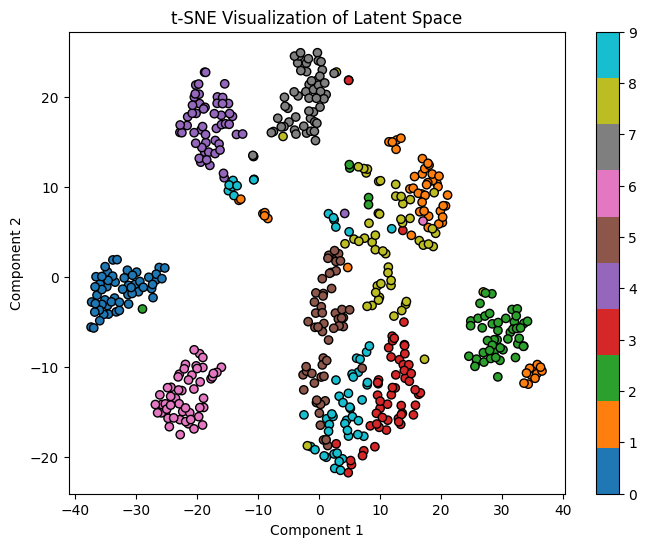

In [10]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_test_latent)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_test, cmap='tab10', edgecolor='k')
plt.colorbar(scatter)
plt.title("t-SNE Visualization of Latent Space")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()


# <font color="magenta"> **Training Curves:**

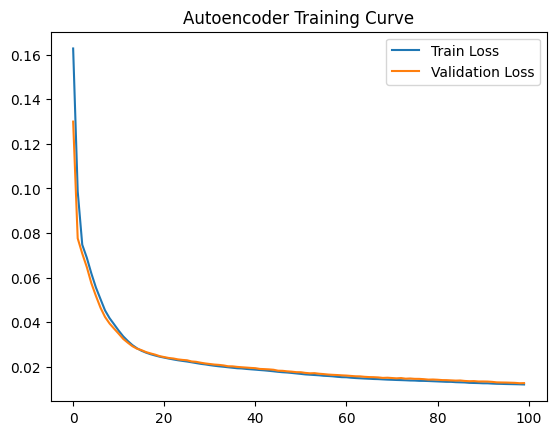

In [11]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Autoencoder Training Curve")
plt.show()

# <font color="magenta"> **Final Observations:**


* The Autoencoder successfully learned compressed feature representations from the original dataset.
* The encoder reduced the dimensionality of the input data while preserving important information.
* Reconstruction loss decreased during training, indicating that the model learned meaningful patterns.
* Reconstructed images were visually similar to the original images with only minor information loss.
* Classification using latent (compressed) features achieved performance close to the classifier trained on raw data.
* Early stopping helped prevent overfitting and improved generalization performance.
* Overall, the Autoencoder successfully learned efficient compressed representations while maintaining good classification performance.





# <font color="green"> **Assignment:**

Implement an undercomplete autoencoder on Fashion-MNIST dataset and carryout all the steps as shown in above autoencoder example.